Laboratory 1: Digital Image Processing

In [1]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from PIL import Image
import cv2

print("Libraries imported successfully")

Libraries imported successfully


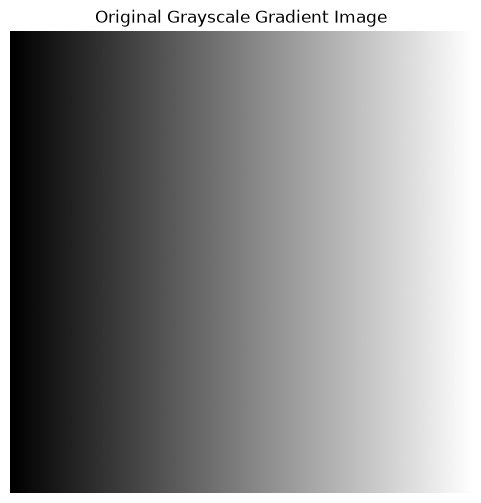

In [4]:
# Create the Original Grayscale Image

width = 512
height = 512

gradient = np.tile(
    np.linspace(0,255, width, dtype=np.uint8),
    (height, 1)
)

plt.figure(figsize=(6,6))
plt.imshow(gradient, cmap="gray", vmin=0, vmax=255)
plt.title("Original Grayscale Gradient Image")
plt.axis("off")
plt.show()

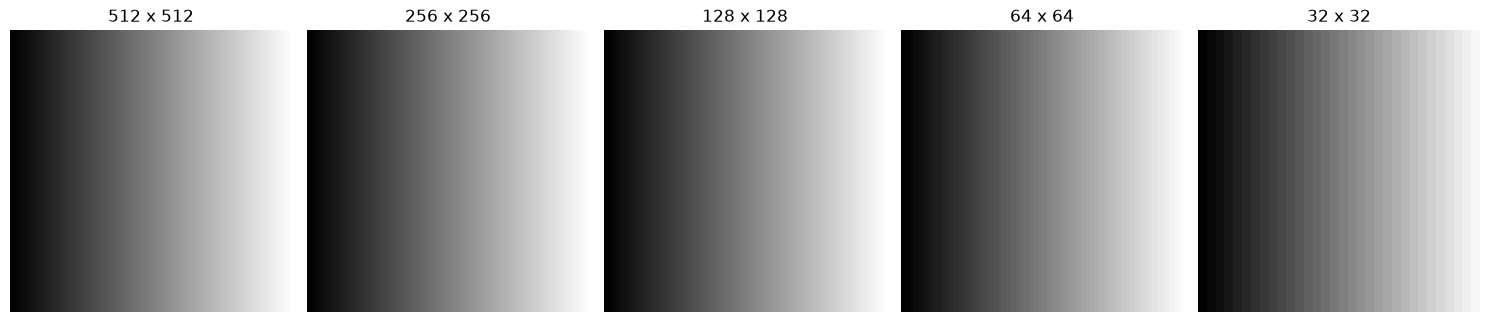

In [6]:
# Spatial Sampling

sizes = [512, 256, 128, 64, 32]

plt.figure(figsize=(15,8))
for i, size in enumerate(sizes):
    small = cv2.resize(
        gradient, (size, size),
        interpolation=cv2.INTER_NEAREST
    )

    plt.subplot(1, 5, i+1)
    plt.imshow(small, cmap="gray", vmin=0, vmax=255)
    plt.title(f"{size} x {size}")
    plt.axis("off")

plt.tight_layout()
plt.show()

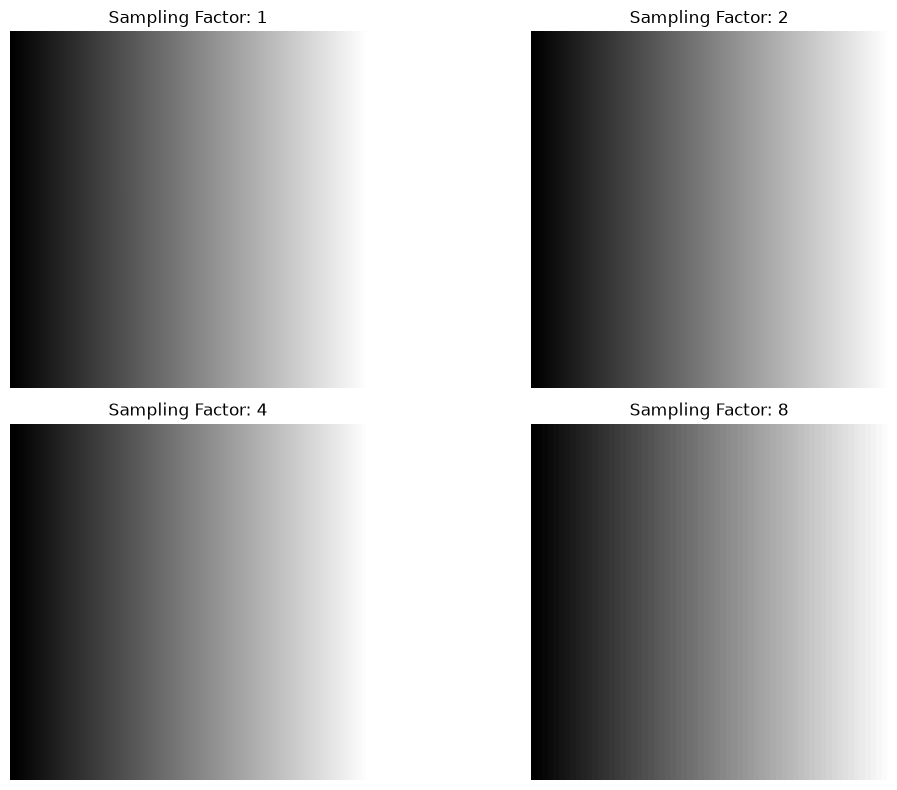

In [ ]:
# Manual Image Sampling

sampling_factors = [1, 2, 4, 8]

plt.figure(figsize=(12,8))
for i, factor in enumerate(sampling_factors):
    sampled = gradient[::factor, ::factor]
    plt.subplot(2,2, i+1)
    plt.imshow(sampled, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Sampling Factor: {factor}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# if factor = 4, every fourth pixel is retained in each direction. The approximate retained pixel count is 1/16 of the original

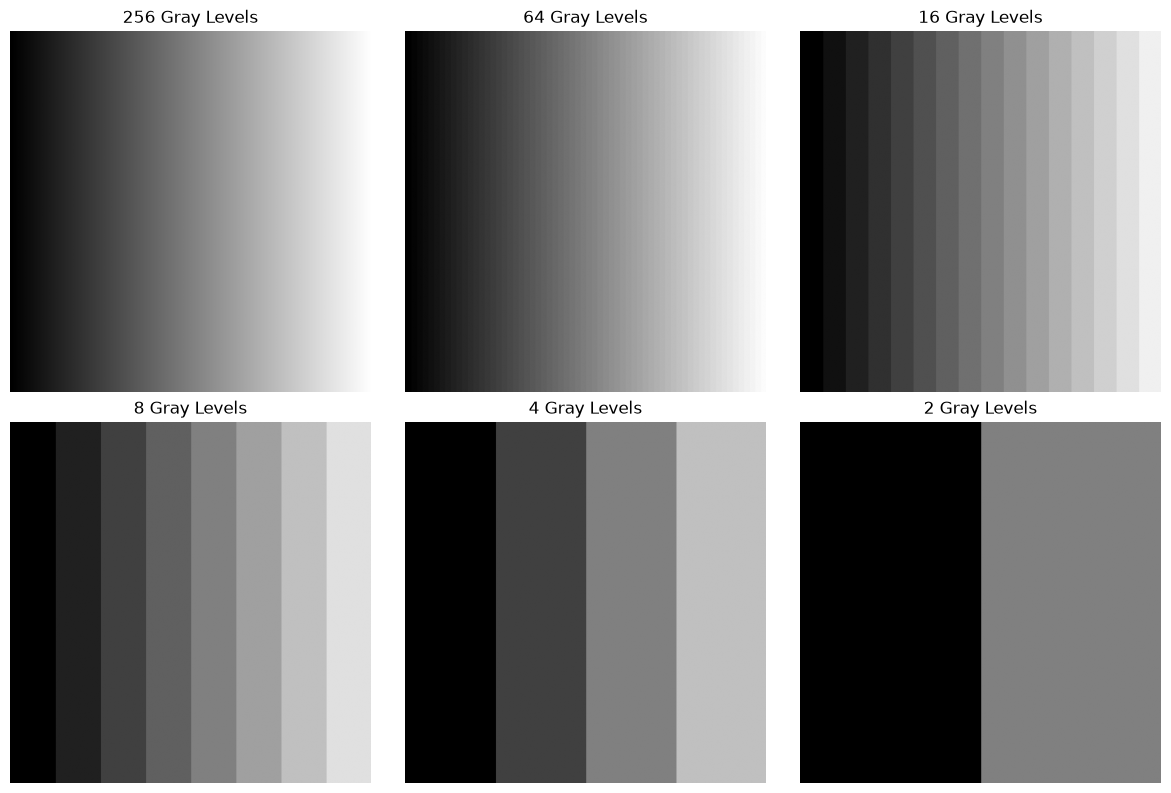

In [10]:
# Quantization

def quantization_image(image, levels):
    step = 256 / levels
    quantisized = np.floor(image / step) * step
    return np.clip(quantisized, 0, 255).astype(np.uint8)

levels = [256, 64, 16, 8, 4, 2]

plt.figure(figsize=(12, 8))
for i, level in enumerate(levels):
    q_image = quantization_image(gradient, level)
    plt.subplot(2, 3, i+1)
    plt.imshow(q_image, cmap="gray", vmin=0, vmax=255)
    plt.title(f"{level} Gray Levels")
    plt.axis("off")

plt.tight_layout()
plt.show()

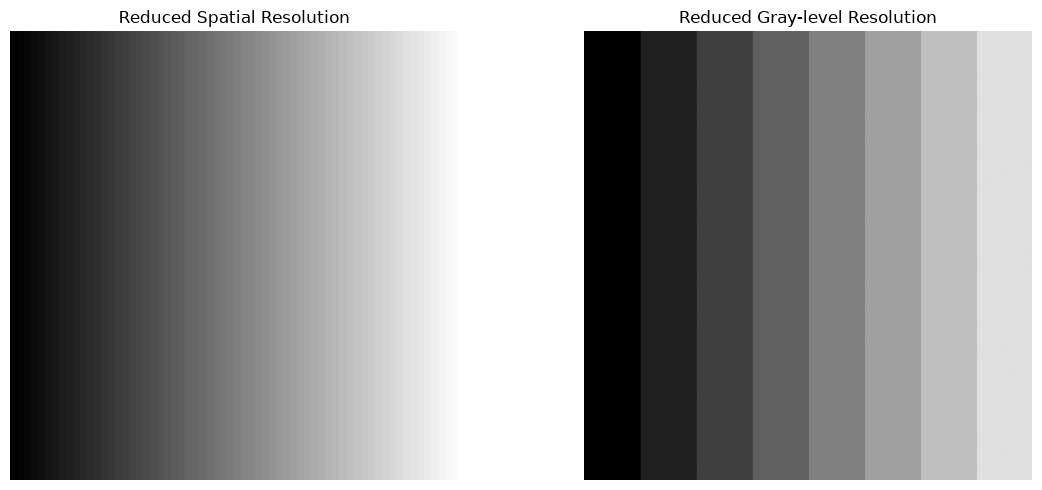

In [13]:
# Spatial vs. Gray-level Resolution

sampled = cv2.resize(
    gradient, (64, 64),
    interpolation=cv2.INTER_NEAREST
)

quantized = quantization_image(gradient, 8)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(sampled, cmap="gray", vmin=0, vmax=255)
plt.title("Reduced Spatial Resolution")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(quantized, cmap="gray", vmin=0, vmax=255)
plt.title("Reduced Gray-level Resolution")
plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
# Bits per Pixel

levels = [2, 4, 8, 16, 32, 64, 128, 256]

for L in levels:
    k = int(np.log2(L))
    print(f"(L:3d) gray levels = {k} bits/pixel")

(L:3d) gray levels = 1 bits/pixel
(L:3d) gray levels = 2 bits/pixel
(L:3d) gray levels = 3 bits/pixel
(L:3d) gray levels = 4 bits/pixel
(L:3d) gray levels = 5 bits/pixel
(L:3d) gray levels = 6 bits/pixel
(L:3d) gray levels = 7 bits/pixel
(L:3d) gray levels = 8 bits/pixel


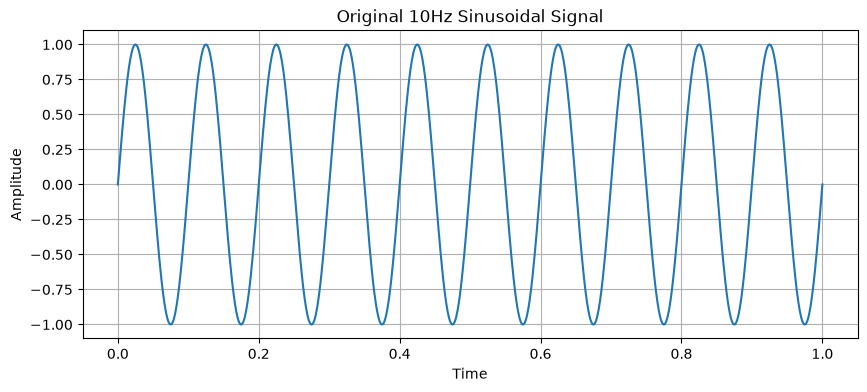

In [ ]:
# Nyquist Concept with 1-D Signal

x = np.linspace(0, 1, 1000)
frequency = 10
signal = np.sin(2*np.pi*frequency*x)

plt.figure(figsize=(10, 4))
plt.plot(x, signal)
plt.title("Original 10Hz Sinusoidal Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# for a 10Hz signal, the theoretical Nyquist rate is 20Hz, which means we need to sample at least 20 times per second to accurately capture the signal. Let's demonstrate this by sampling the signal at different rates

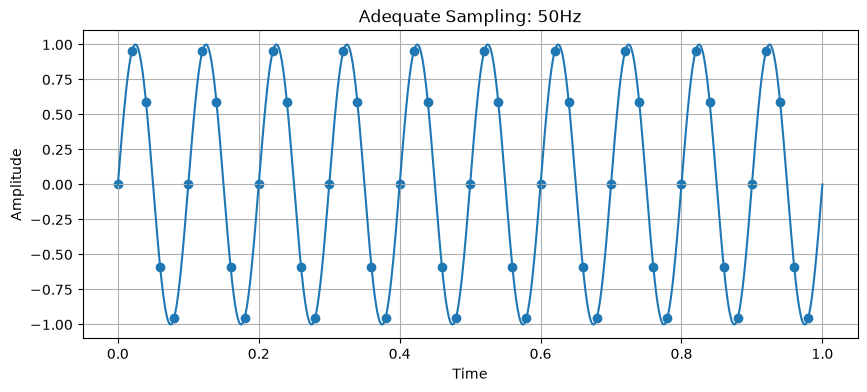

In [21]:
# Adequate Sampling

fs = 50
sample_times = np.arange(0, 1, 1/fs)
sampled_signal = np.sin(2*np.pi*frequency*sample_times)

plt.figure(figsize=(10, 4))
plt.plot(x,signal)
plt.scatter(sample_times, sampled_signal)
plt.title("Adequate Sampling: 50Hz")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

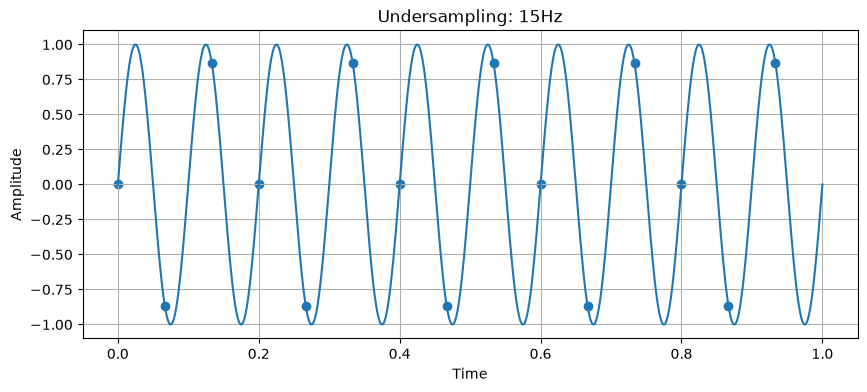

In [22]:
# Undersampling and Aliasing

fs = 15
sample_times = np.arange(0, 1, 1/fs)
sampled_signal = np.sin(2*np.pi*frequency*sample_times)

plt.figure(figsize=(10, 4))
plt.plot(x, signal)
plt.scatter(sample_times, sampled_signal)
plt.title("Undersampling: 15Hz")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

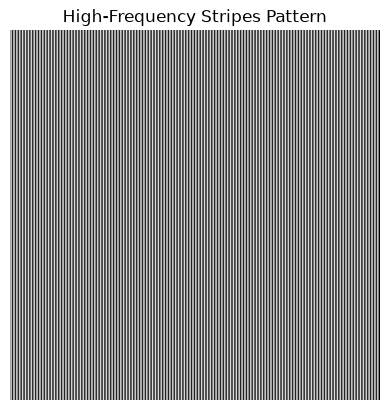

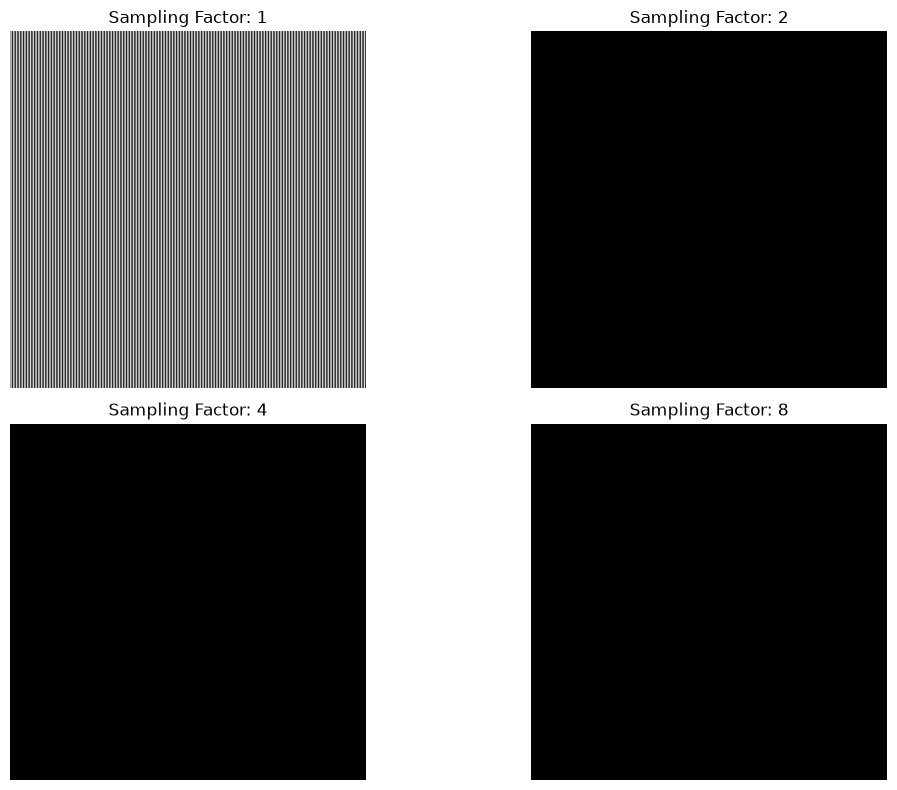

In [26]:
# Image Aliasing

size = 512
x = np.arange(size)
stripes = ((np.sin(2*np.pi*0.25*x) + 1) *126.5).astype(np.uint8)
stripes_image = np.tile(stripes, (size, 1))
plt.imshow(stripes_image, cmap="gray")
plt.title("High-Frequency Stripes Pattern")
plt.axis("off")
plt.show()

factors = [1,2,4,8]
plt.figure(figsize=(12, 8))
for i, factor in enumerate(factors):
    sampled_stripes = stripes_image[::factor, ::factor]
    plt.subplot(2, 2, i+1)
    plt.imshow(sampled_stripes, cmap="gray")
    plt.title(f"Sampling Factor: {factor}")
    plt.axis("off")

plt.tight_layout()
plt.show()

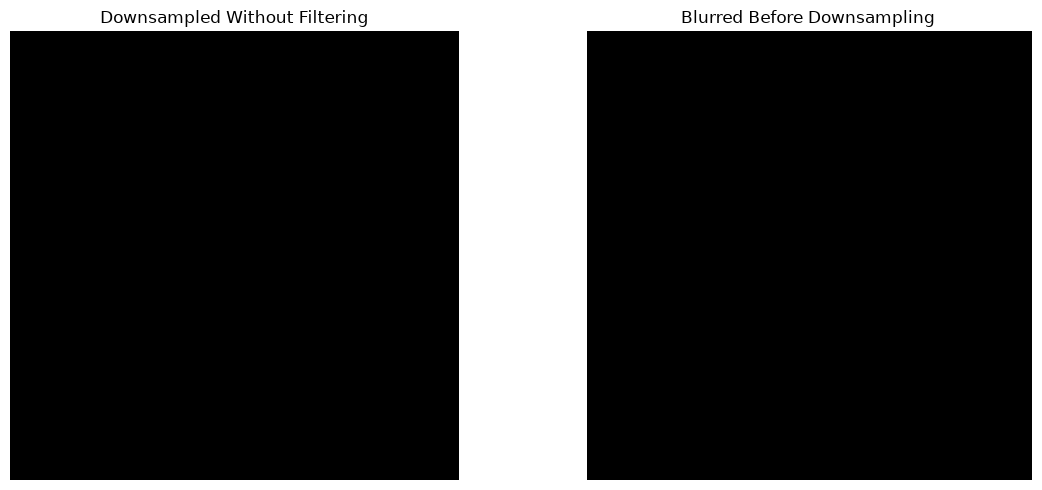

In [29]:
# Anti-Aliasing using Gaussian Blur

blurred = cv2.GaussianBlur(stripes_image, (9, 9), 0)
downsampled = blurred[::4, ::4]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(stripes_image[::4, ::4], cmap="gray")
plt.title("Downsampled Without Filtering")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(downsampled, cmap="gray")
plt.title("Blurred Before Downsampling")
plt.axis("off")

plt.tight_layout()
plt.show()


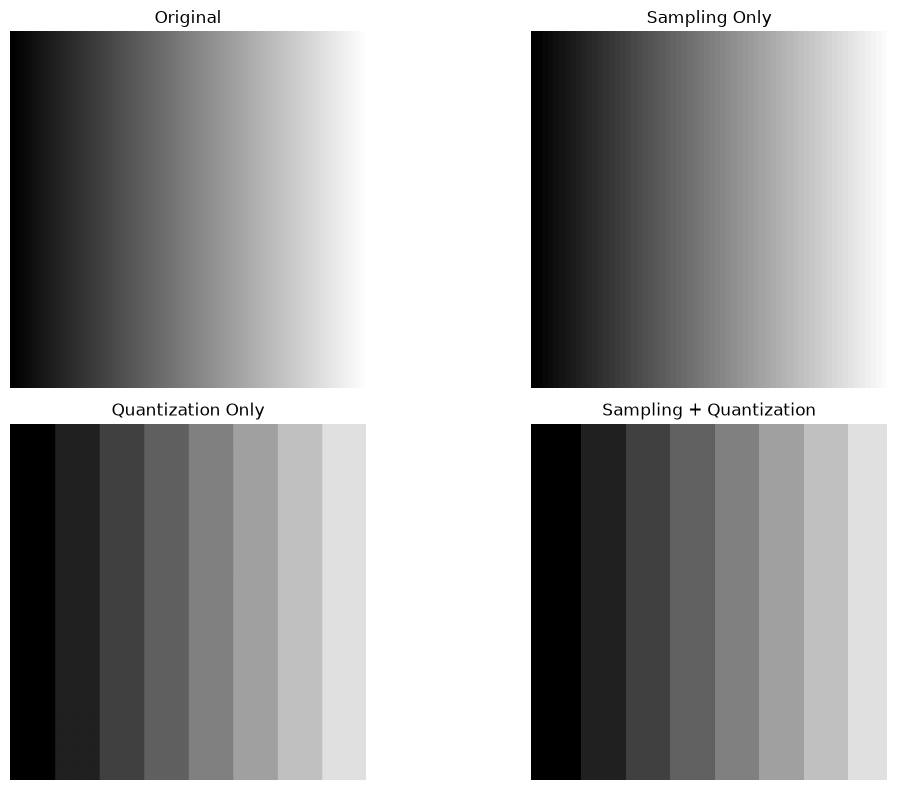

In [33]:
# Integrated Sampling and Quantization

original = gradient

sampled = cv2.resize(
    original, (64,64),
    interpolation=cv2.INTER_NEAREST
)

quantized = quantization_image(original, 8)
sampled_quantized = quantization_image(sampled, 8)

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.imshow(original, cmap="gray", vmin=0, vmax=255)
plt.title("Original"); plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(sampled, cmap="gray", vmin=0, vmax=255)
plt.title("Sampling Only"); plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(quantized, cmap="gray", vmin=0, vmax=255)
plt.title("Quantization Only"); plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(sampled_quantized, cmap="gray", vmin=0, vmax=255)
plt.title("Sampling + Quantization"); plt.axis("off")

plt.tight_layout()
plt.show()


Performance Challenge: Create process_image(image, spatial_size, gray_levels). The function should convert the image to grayscale, resize/sample it, quantize it, display the original and processed images, and print dimensions, gray levels, and bits per pixel.

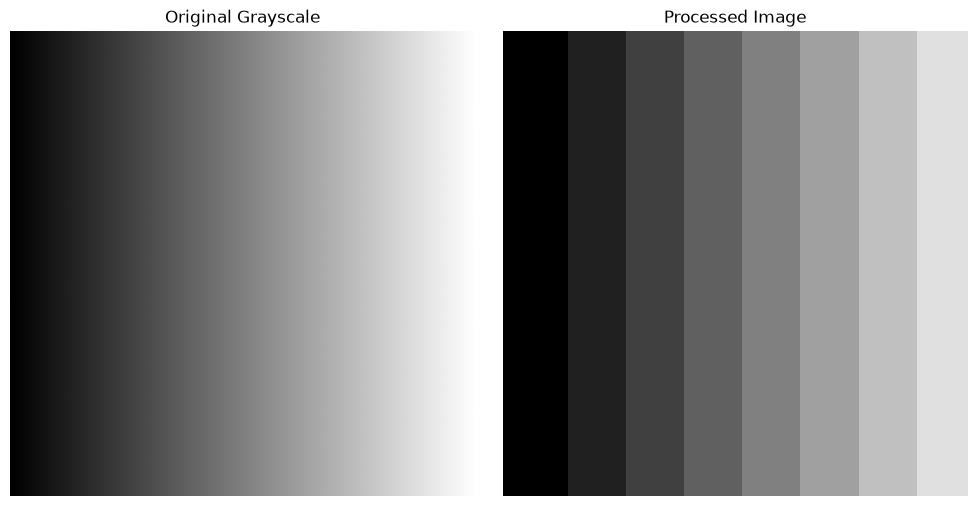

Original dimensions: (512, 512)
Processed dimensions: (64, 64)
Gray levels: 8
Bits per pixel: 3


In [36]:
# Convert to grayscale > Resize > Quantize > Display result > Print image information

def quantize_image(image, levels):
    step = 256 / levels
    quantized = np.floor(image / step) * step
    return np.clip(quantized, 0, 255).astype(np.uint8)


def process_image(image, spatial_size, gray_levels):

    # 1. Convert to grayscale
    if len(image.shape) == 3:
        grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        grayscale = image

    # 2. Resize / sample
    processed = cv2.resize(
        grayscale,
        (spatial_size, spatial_size),
        interpolation=cv2.INTER_NEAREST
    )

    # 3. Quantize
    processed = quantize_image(processed, gray_levels)

    # 4. Display result
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(grayscale, cmap="gray", vmin=0, vmax=255)
    plt.title("Original Grayscale")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(processed, cmap="gray", vmin=0, vmax=255)
    plt.title("Processed Image")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # 5. Print image information
    print("Original dimensions:", grayscale.shape)
    print("Processed dimensions:", processed.shape)
    print("Gray levels:", gray_levels)
    print("Bits per pixel:", int(np.log2(gray_levels)))

    return processed


# pass
result = process_image(gradient, 64, 8)

Part I: Enrichment Activity

In [5]:
image_path = "goku.jpg"

# load the image
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError("Image not found at path:")

# convert BGR to RGB for matplotlib 
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


In [6]:
# Function: reduce gray-level resolution

def reduce_gray_levels(img, levels=4):
    step = 256 / levels
    reduced = np.floor(img / step) * step
    return np.clip(reduced, 0, 255).astype(np.uint8)

In [7]:
# Function: reduce spatial resolution

def reduce_spatial_resolution(img, scale=0.15):
     height, width = img.shape[:2]

     small_width = max(1, int(width * scale))
     small_height = max(1, int(height * scale))

     # reduce resolution
     small = cv2.resize(
        img,
        (small_width, small_height),
        interpolation=cv2.INTER_AREA
    )

     # resize back to original size
     enlarged = cv2.resize(
        small,
        (width, height),
        interpolation=cv2.INTER_NEAREST
    )
     
     return enlarged

In [8]:
# Case 1: high spatial + high gray-level resolution

case1 = image.copy()

# Case 2: high spatial + low gray-level resolution

case2 = reduce_gray_levels(
    image,
    levels=4
)

# Case 3: low spatial + high gray-level resolution

case3 = reduce_spatial_resolution(
    image,
    scale=0.15
)

# Case 4: low spatial + low gray-level resolution

case4 = reduce_spatial_resolution(
    image,
    scale=0.15
)

case4 = reduce_gray_levels(
    case4,
    levels=4
)

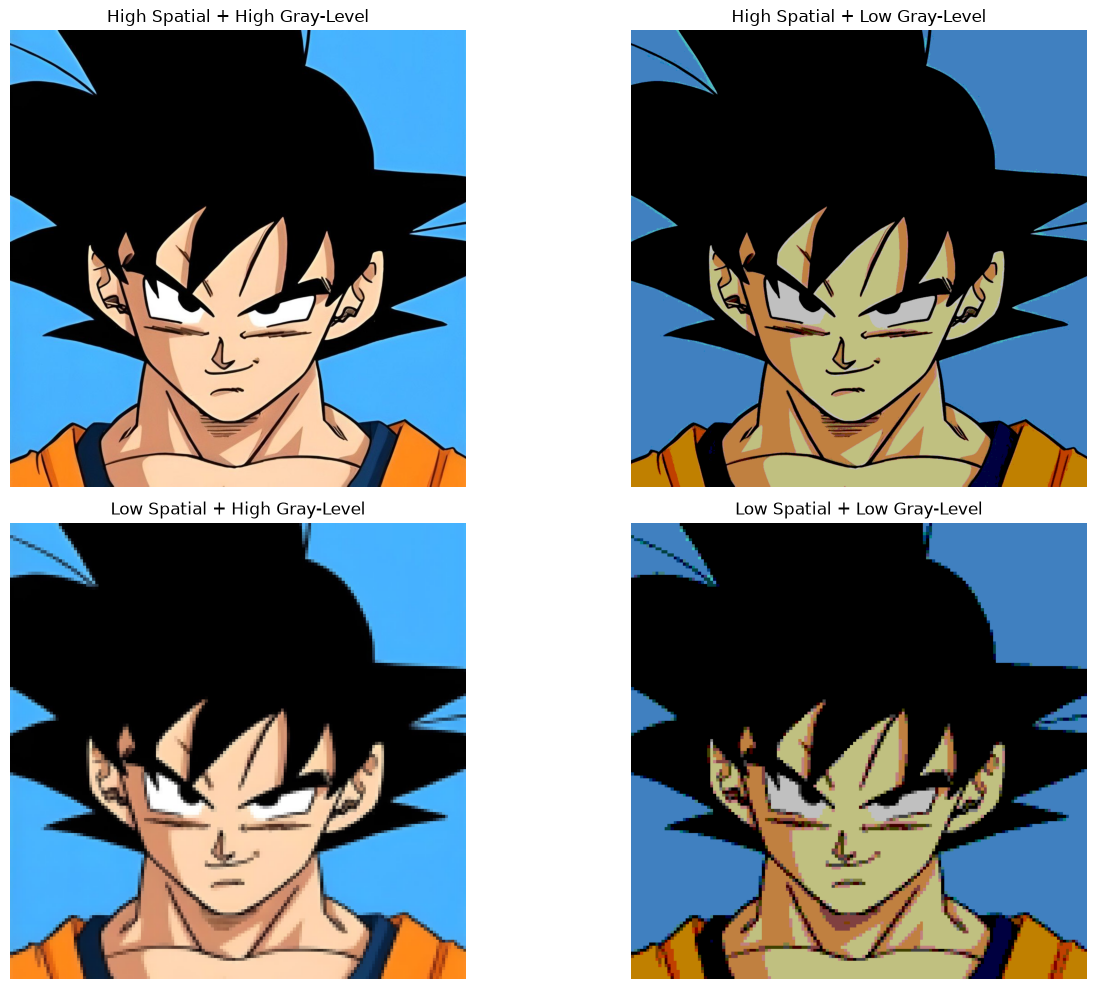

In [10]:
# Display four cases

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.imshow(case1)
plt.title("High Spatial + High Gray-Level")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(case2)
plt.title("High Spatial + Low Gray-Level")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(case3)
plt.title("Low Spatial + High Gray-Level")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(case4)
plt.title("Low Spatial + Low Gray-Level")
plt.axis("off")

plt.tight_layout()
plt.show()